# Deutsche Netzlast — explorative Analyse

Stündliche Netzlast für Deutschland von [SMARD](https://www.smard.de), ergänzt um
Temperatur (Open-Meteo), Day-Ahead-Preis und Erzeugungsmix (Energy-Charts). Ziel dieses
Notebooks ist es, die Struktur zu verstehen, die eine Prognose ausnutzen muss: die
tägliche, wöchentliche und jährliche Saisonalität, den Feiertagseffekt, die Datenqualität
und den Zusammenhang von Last mit Temperatur und Preis.

**Kernbefund vorweg:** Die Last folgt drei klaren Zyklen (Stunde, Wochentag, Monat), reagiert
an Feiertagen wie an Sonntagen und ist über 24 h und 168 h stark autokorreliert. Genau
diese Struktur begründet die späteren Kalender- und Lag-Merkmale.

### Datenauswahl und Vorverarbeitung

- **Ziel — SMARD-Netzlast:** die offizielle, token-freie Quelle der Bundesnetzagentur, in
  konsistenter Stundenauflösung. Sie bildet die real gemessene Last ab, nicht eine Prognose.
- **Zeitraum ab 2021:** gut fünf Jahre Historie — lang genug, damit der spätere
  rollierende Backtest mehrere Jahre mit unterschiedlichen Wetter- und Marktphasen abdeckt.
- **Stündliche Auflösung:** fein genug für die Tages-/Wochenstruktur, ohne den Datensatz
  unnötig aufzublähen; sub-stündliche Quellen werden auf Stundenmittel resampled.
- **Zeitzone Europe/Berlin:** alle Reihen werden aus UTC umgerechnet, damit die
  Sommer-/Winterzeit-Umstellung auf der korrekten Wanduhr-Stunde landet.
- **Exogene Treiber:** Temperatur (bevölkerungsgewichtet über die sechs größten Städte),
  Preis und Erzeugungsmix — Letztere gehen später nur *verzögert* ein, weil ihr aktueller
  Wert zum Prognosezeitpunkt nicht bekannt ist.

Aufbau und Zusammenführung der Daten liegen in `src/data.py`.

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src import config

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 4)

df = pd.read_parquet(config.DATASET_PARQUET)
load = df[config.TARGET]
print(df.shape, "|", df.index.min(), "->", df.index.max())
df.head()

(48287, 7) | 2021-01-01 00:00:00+01:00 -> 2026-07-05 23:00:00+02:00


,load_MW,load_imputed,temp_DE,price_EUR_MWh,solar_MW,wind_MW,renewable_share
timestamp,,,,,,,
2021-01-01 00:00:00+01:00,44569.25,False,NaN,50.87,0.0,4342.175,0.25300
2021-01-01 01:00:00+01:00,42806.00,False,0.748750,48.19,0.0,3950.200,0.25325
2021-01-01 02:00:00+01:00,41049.75,False,0.694688,44.68,0.0,3528.500,0.25275
2021-01-01 03:00:00+01:00,40233.75,False,0.591563,42.92,0.0,3110.100,0.24700
2021-01-01 04:00:00+01:00,40210.50,False,0.749688,40.39,0.7,2778.300,0.23800


## Die Lastreihe

Die Netzlast in MW über den gesamten Zeitraum, dazu ein Zwei-Wochen-Ausschnitt. Zwei
Dinge fallen sofort auf: der starke **Jahreszyklus** (Winterspitzen, Sommertäler) und die
**Wochentextur** — werktags ein ausgeprägter Tagesgang mit Morgen- und Abendspitze, am
Wochenende deutlich flacher. Der Ausschnitt macht diese Tages- und Wochenform sichtbar,
die im Gesamtplot in der Punktdichte untergeht.

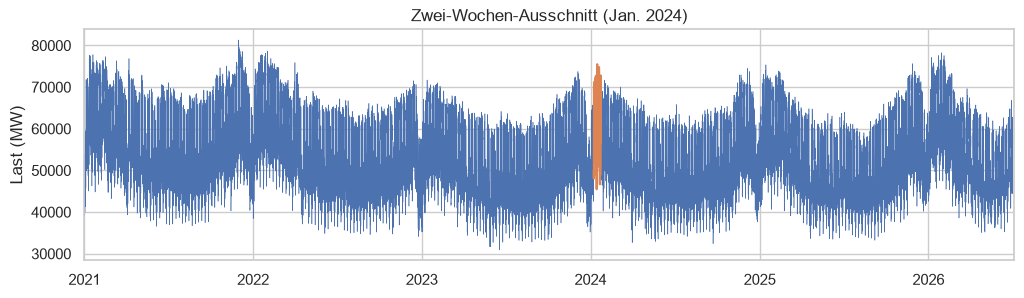

In [2]:
fig, ax = plt.subplots(figsize=(12, 4))
load.plot(ax=ax, lw=0.4)
ax.set(ylabel="Last (MW)", xlabel="", title="Deutsche Netzlast, stündlich")
# Zwei-Wochen-Ausschnitt, um die Tages-/Wochenform zu zeigen
ax2 = load.loc["2024-01-08":"2024-01-22"].plot(figsize=(12, 3), title="Zwei-Wochen-Ausschnitt (Jan. 2024)")
ax2.set(ylabel="Last (MW)", xlabel="")
plt.show()

## Saisonalität: täglich, wöchentlich, jährlich

Die Durchschnittslast nach Stunde, Wochentag und Monat — die drei Zyklen, die ein Modell
erfassen muss. Der Tagesgang zeigt die Morgen- und Abendspitze, die Wochenkurve den
Werktag-Wochenende-Unterschied, die Monatskurve den Heizbedarf im Winter. Weil diese
Muster deterministisch aus dem Zeitstempel folgen, werden sie später als **Kalender-
merkmale** kodiert (Stunde und Wochentag zusätzlich zyklisch als Sinus/Kosinus).

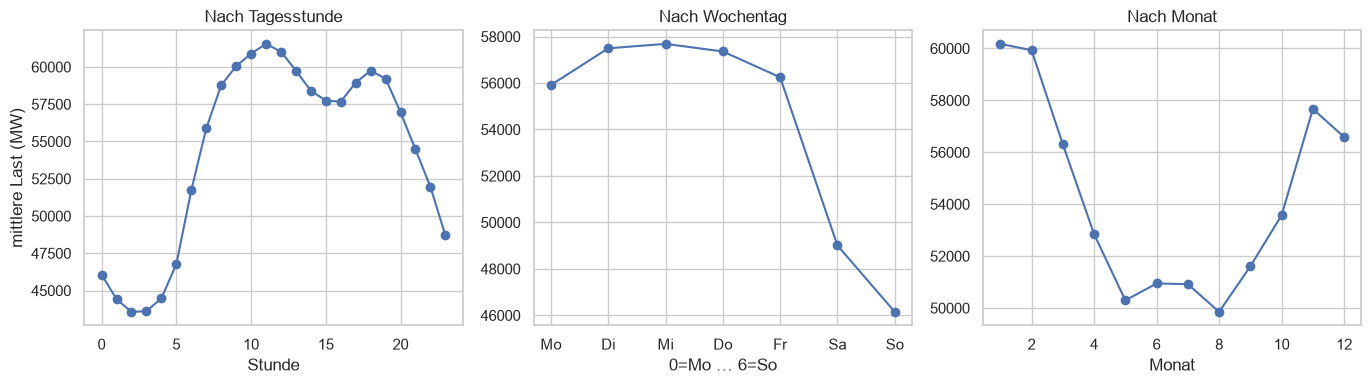

In [3]:
by_hour = load.groupby(load.index.hour).mean()
by_dow = load.groupby(load.index.dayofweek).mean()
by_month = load.groupby(load.index.month).mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
by_hour.plot(ax=axes[0], marker="o"); axes[0].set(title="Nach Tagesstunde", xlabel="Stunde", ylabel="mittlere Last (MW)")
by_dow.plot(ax=axes[1], marker="o"); axes[1].set(title="Nach Wochentag", xlabel="0=Mo … 6=So")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(["Mo","Di","Mi","Do","Fr","Sa","So"])
by_month.plot(ax=axes[2], marker="o"); axes[2].set(title="Nach Monat", xlabel="Monat")
plt.tight_layout(); plt.show()

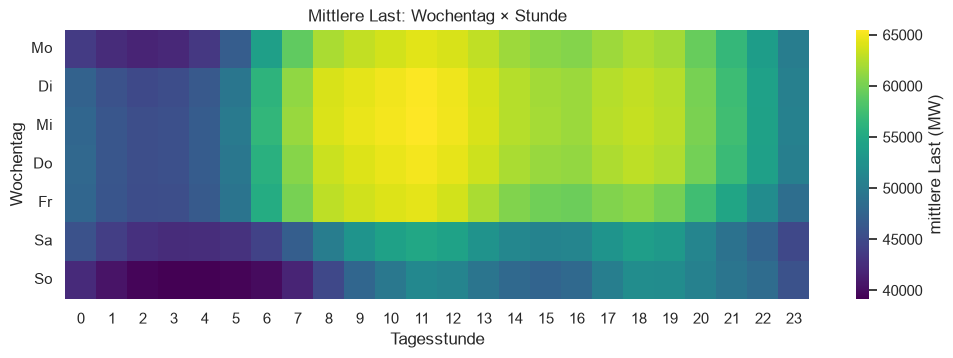

In [4]:
# Heatmap Stunde × Wochentag: werktägliche Pendlerspitzen vs. flaches Wochenende
pivot = load.groupby([load.index.dayofweek, load.index.hour]).mean().unstack()
fig, ax = plt.subplots(figsize=(12, 3.5))
sns.heatmap(pivot, cmap="viridis", ax=ax, cbar_kws={"label": "mittlere Last (MW)"})
ax.set(xlabel="Tagesstunde", ylabel="Wochentag", title="Mittlere Last: Wochentag × Stunde")
ax.set_yticklabels(["Mo","Di","Mi","Do","Fr","Sa","So"], rotation=0)
plt.show()

## Feiertagseffekt

Gesetzliche Feiertage verhalten sich unabhängig vom Wochentag wie Sonntage — die Last
liegt spürbar unter einem normalen Werktag. Das rechtfertigt ein **explizites
Feiertagsmerkmal**: Ohne es würde das Modell etwa einen Feiertag, der auf einen Dienstag
fällt, als Werktag mit hoher Last fehleinschätzen. Verwendet werden bundesweite Feiertage.

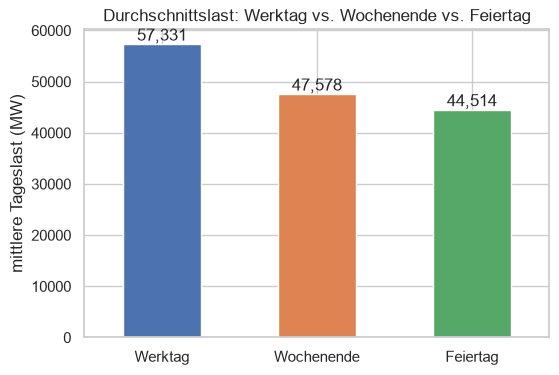

In [5]:
import holidays
de = holidays.Germany()
is_hol = pd.Series([d.date() in de for d in load.index], index=load.index)
daily = load.resample("D").mean()
daily_hol = pd.Series([d.date() in de for d in daily.index], index=daily.index)
comp = pd.DataFrame({
    "Werktag": daily[(daily.index.dayofweek < 5) & (~daily_hol)],
    "Wochenende": daily[daily.index.dayofweek >= 5],
    "Feiertag": daily[daily_hol],
})
ax = comp.mean().plot.bar(color=["#4c72b0","#dd8452","#55a868"], figsize=(6,4), rot=0)
ax.set(ylabel="mittlere Tageslast (MW)", title="Durchschnittslast: Werktag vs. Wochenende vs. Feiertag")
for i, v in enumerate(comp.mean()):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom")
plt.show()

## Datenqualität: Lücken und Imputation

Beim Einlesen markierte Stunden (`load_imputed`) und verbleibende fehlende Werte. Kurze
Lücken (≤ 3 h) wurden linear interpoliert und als imputiert gekennzeichnet; längere Löcher
bleiben bewusst `NaN`. Die Entscheidung dahinter: Über kurze Lücken lässt sich sauber
interpolieren, ohne Struktur zu erfinden — über lange Ausfälle würde Interpolation Daten
vortäuschen, die es nie gab, und die Modellbewertung verzerren.

Zeilen: 48,287
imputiert (kurze Lücken): 77
weiterhin fehlende Last:  77

fehlende % je Spalte:
 load_MW            0.159
solar_MW           0.159
renewable_share    0.159
wind_MW            0.157
price_EUR_MWh      0.149
temp_DE            0.147


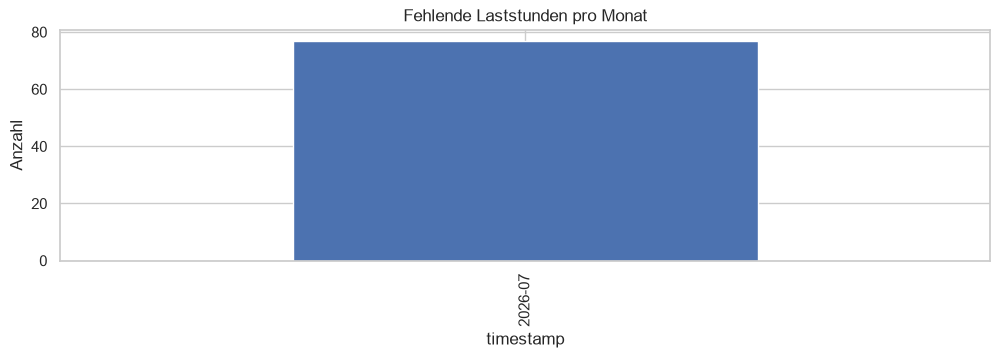

In [6]:
n = len(df)
print(f"Zeilen: {n:,}")
print(f"imputiert (kurze Lücken): {int(df['load_imputed'].sum())}")
print(f"weiterhin fehlende Last:  {int(load.isna().sum())}")
miss = df.drop(columns='load_imputed').isna().mean().sort_values(ascending=False) * 100
print("\nfehlende % je Spalte:\n", miss.round(3).to_string())
# Wo liegen die Lücken?
gaps = load[load.isna()]
if len(gaps):
    g = gaps.resample("MS").size()
    g = g[g > 0]
    g.index = g.index.strftime("%Y-%m")
    ax = g.plot(kind="bar", figsize=(12,3))
    ax.set(title="Fehlende Laststunden pro Monat", ylabel="Anzahl"); plt.show()
else:
    print("\nkeine verbleibenden fehlenden Laststunden")

## Verteilung und Autokorrelation

Die Verteilung der Last und ihre Autokorrelation. Entscheidend sind die deutlichen Spitzen
der ACF bei **24 h** und **168 h**: Die Last ähnelt sich am stärksten jener von vor genau
einem Tag und vor genau einer Woche. Genau das rechtfertigt die späteren **Lag-Merkmale**
(24 h, 48 h, 168 h). Die PACF zeigt, welche dieser Zusammenhänge direkt wirken und welche
nur über Zwischenlags vermittelt sind.

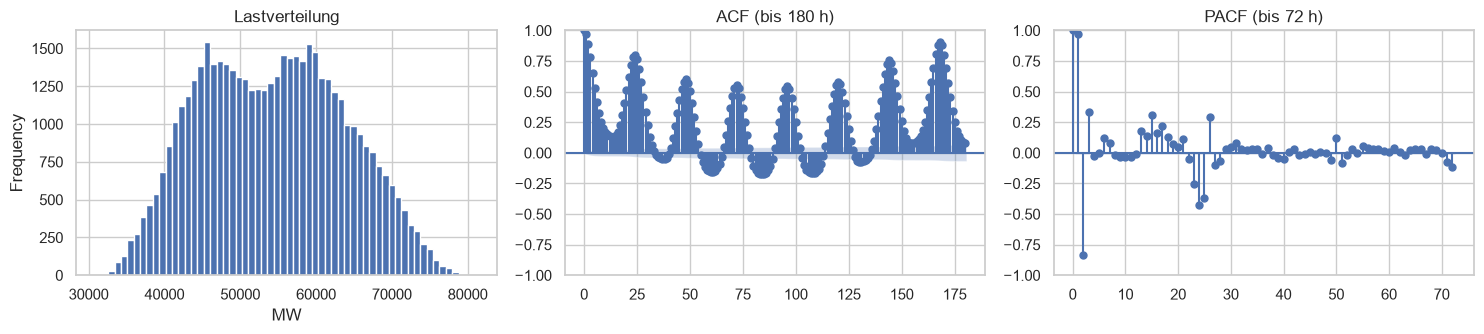

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
load.plot.hist(bins=60, ax=axes[0]); axes[0].set(title="Lastverteilung", xlabel="MW")
s = load.dropna()
plot_acf(s, lags=180, ax=axes[1]); axes[1].set(title="ACF (bis 180 h)")
plot_pacf(s, lags=72, ax=axes[2], method="ywm"); axes[2].set(title="PACF (bis 72 h)")
plt.tight_layout(); plt.show()

## Last vs. Wetter und Preis

Die Temperatur treibt die Nachfrage: Heizen unter ~15 °C, etwas Kühlen im Sommer → eine
**U-Form**. Das macht die Temperatur zum wichtigsten exogenen Treiber. Preis und Last
hängen positiv zusammen, aber verrauscht — hohe Last geht tendenziell mit höheren
Day-Ahead-Preisen einher. Der Preis geht später nur **verzögert** ein, da der aktuelle
Preis zum Prognosezeitpunkt noch nicht bekannt ist.

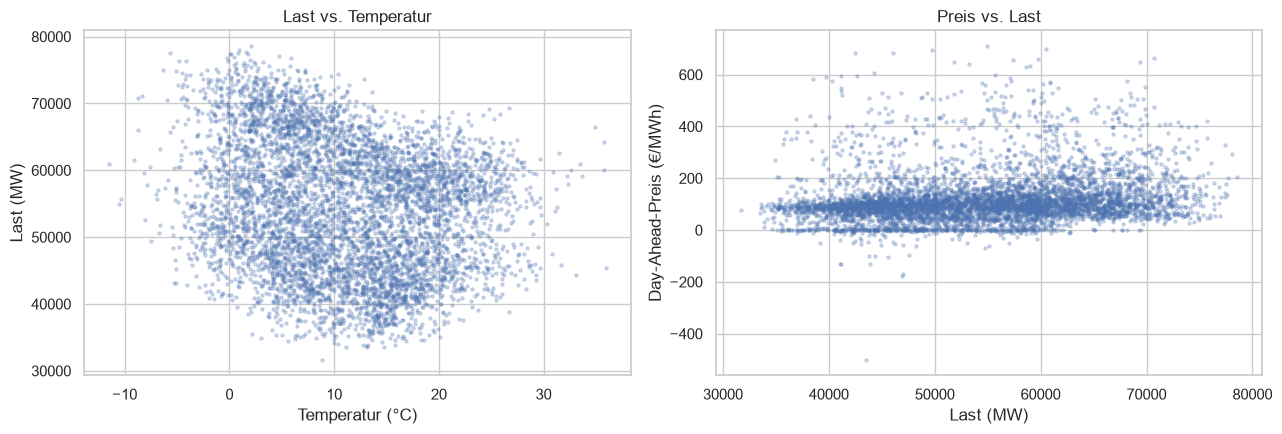

In [8]:
sample = df.dropna(subset=[config.TARGET, "temp_DE", "price_EUR_MWh"]).sample(
    min(6000, len(df)), random_state=config.SEED)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(sample["temp_DE"], sample[config.TARGET], s=5, alpha=0.25)
axes[0].set(xlabel="Temperatur (°C)", ylabel="Last (MW)", title="Last vs. Temperatur")
axes[1].scatter(sample[config.TARGET], sample["price_EUR_MWh"], s=5, alpha=0.25)
axes[1].set(xlabel="Last (MW)", ylabel="Day-Ahead-Preis (€/MWh)", title="Preis vs. Last")
plt.tight_layout(); plt.show()

## Fazit für die Modellierung

- **Drei Saisonalitäten** (Stunde, Wochentag, Monat) plus ein klarer **Feiertagseffekt** → Kalendermerkmale.
- Starke **24-h- und 168-h-Autokorrelation** → verzögerte Lastmerkmale (Lags) sind das Rückgrat.
- Die **Temperatur** hat einen U-förmigen Zusammenhang mit der Last → ein nützlicher exogener Treiber.
- Die Datenqualität ist gut; nur wenige kurze Lücken mussten interpoliert werden.

Weiter geht es mit den Baselines (naiv / saisonal-naiv) und einem rollierenden Backtest — siehe `src/evaluate.py`.